# 🧊 **3DSC Dataset**  
This notebook aims to explore the [3DSC](https://github.com/aimat-lab/3DSC) dataset, a database published in 2023 by Sommer *et al* that contains the critical temperature of superconductor materials (as well as non-superconducting compounds) along with properties related to their chemical formulas and approximate 3D crystal structures. The inclusion of structural information represents its main distinguishing feature compared to other available datasets. [1]
***

### 📚 **Importing libraries & Data**

In [1]:
import optuna

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cluster import Birch, BisectingKMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.genmod.families.links import Identity
import statsmodels.api as sm

import pygam
from pygam import s

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/3DSC_MP.csv", skiprows=1)
display(df)

,formula_sc,formula_similarity,totreldiff,formula_frac,correct_formula_frac,formula_2,orig_formula_cif,tc,sc_class,sc_class_unique_sc,...,monoclinic,orthorhombic,tetragonal,triclinic,trigonal,primitive,base-centered,body-centered,face-centered,weight
0,Ag0.02Ge2Pd1.98Sr1,2,0.008000,1.0,True,Ag0.02Ge2Pd1.98Sr1,Ge2Pd2Sr1,2.640000,Other,True,...,0,0,7,0,0,0,0,1,0,1.0
1,Ag0.15Sn0.85Te1,3,0.150000,1.0,True,Ag0.15Sn0.85Te1,Sn1Te1,2.150000,Other,True,...,0,0,0,0,0,0,0,0,1,1.0
2,Ag0.1Ge2Pd1.9Sr1,2,0.040000,1.0,True,Ag0.1Ge2Pd1.9Sr1,Ge2Pd2Sr1,2.620000,Other,True,...,0,0,7,0,0,0,0,1,0,1.0
3,Ag0.1In0.9Te1,3,0.100000,1.0,True,Ag0.1In0.9Te1,In1Te1,1.200000,Other,True,...,0,0,0,0,0,0,0,0,1,1.0
4,Ag0.2Ba1Si1.8,3,0.133333,4.0,False,Ag0.8Ba4Si7.2,Ba4Si8,3.200000,Other,True,...,0,0,0,0,0,1,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,Y1Zn1,1,0.000000,1.0,True,Y1Zn1,Y1Zn1,0.000000,Other,True,...,0,0,0,0,0,1,0,0,0,1.0
5769,Yb1,1,0.000000,3.0,False,Yb3,Yb3,0.000000,Heavy_fermion,True,...,0,0,0,0,6,1,0,0,0,1.0
5770,Zn1,1,0.000000,2.0,False,Zn2,Zn2,0.850800,Other,True,...,0,0,0,0,0,1,0,0,0,1.0
5771,Zn2Zr1,1,0.000000,2.0,False,Zn4Zr2,Zn4Zr2,0.296667,Other,True,...,0,0,0,0,0,0,0,0,1,1.0


### 🕵️‍♀️ **Exploring data**

First of all, let´s see all the features present in the dataset.

In [3]:
df.columns

Index(['formula_sc', 'formula_similarity', 'totreldiff', 'formula_frac',
       'correct_formula_frac', 'formula_2', 'orig_formula_cif', 'tc',
       'sc_class', 'sc_class_unique_sc', 'norm_formula_sc',
       'chemical_composition_sc', 'num_elements_sc', 'origin_sc',
       'old_formula_sc', 'database_id_2', 'original_formula_2',
       'chemical_composition_2', 'norm_formula_2', 'spacegroup_2',
       'crystal_system_2', 'lata_2', 'latb_2', 'latc_2', 'cif',
       'original_cif_2', 'material_id_2', 'band_gap_2', 'band_structure_2',
       'created_at_2', 'density_2', 'doi_2', 'doi_bibtex_2', 'dos_2',
       'e_above_hull_2', 'efermi_2', 'encut_2', 'energy_2',
       'energy_per_atom_2', 'exp_2', 'final_energy_2',
       'final_energy_per_atom_2', 'formation_energy_per_atom_2', 'has_2',
       'has_bandstructure_2', 'icsd_ids_2', 'is_ordered_2', 'last_updated_2',
       'magnetic_type_2', 'nsites_2', 'ntask_ids_2', 'original_task_id_2',
       'oxide_type_2', 'pretty_formula_2', 'pseu

In [4]:
x = df.drop(columns="tc")
y = df["tc"]

There are many columns! We can use statistical to understand a bit about this data.

In [5]:
df.describe()

,formula_similarity,totreldiff,formula_frac,tc,num_elements_sc,lata_2,latb_2,latc_2,band_gap_2,density_2,...,monoclinic,orthorhombic,tetragonal,triclinic,trigonal,primitive,base-centered,body-centered,face-centered,weight
count,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,...,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000,5773.000000
mean,1.892950,0.032930,2.246826,9.936737,3.175472,4.652832,5.078374,7.465058,0.049687,7.709163,...,0.101161,1.182747,2.187771,0.007968,0.274727,0.565564,0.095618,0.231249,0.107570,0.997575
std,0.830158,0.041665,2.447629,19.042684,1.116658,1.360511,1.725634,3.633141,0.296175,3.013332,...,0.559199,2.588362,3.182170,0.118924,1.216390,0.495726,0.294091,0.421668,0.309863,0.034740
min,1.000000,0.000000,0.018180,0.000000,1.000000,2.259826,2.259825,2.471225,0.000000,0.137583,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
25%,1.000000,0.000000,1.000000,0.000000,2.000000,3.856730,3.952285,5.215254,0.000000,6.101417,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2.000000,0.013333,2.000000,2.400000,3.000000,4.239652,4.702381,6.666830,0.000000,7.014958,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,3.000000,0.056000,2.000000,9.603750,4.000000,5.314807,5.564942,8.631810,0.000000,8.873378,...,0.000000,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,3.000000,0.150000,64.000000,132.900000,7.000000,17.102755,21.405657,46.742527,6.593300,22.754912,...,5.000000,7.000000,7.000000,2.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000


With this, we can see that only 42 columns are numerical and, consequently, can be used directly to train the model. So let´s save these columns. 

In [6]:
x_num = x.select_dtypes(include=["float64", "int64"])
x_num

,formula_similarity,totreldiff,formula_frac,num_elements_sc,lata_2,latb_2,latc_2,band_gap_2,density_2,e_above_hull_2,...,monoclinic,orthorhombic,tetragonal,triclinic,trigonal,primitive,base-centered,body-centered,face-centered,weight
0,2,0.008000,1.0,4,4.438672,4.438672,6.030548,0.0000,7.295677,0.000000,...,0,0,7,0,0,0,0,1,0,1.0
1,3,0.150000,1.0,3,4.537670,4.537670,4.537670,0.6624,6.190810,0.000000,...,0,0,0,0,0,0,0,0,1,1.0
2,2,0.040000,1.0,4,4.438672,4.438672,6.030548,0.0000,7.295677,0.000000,...,0,0,7,0,0,0,0,1,0,1.0
3,3,0.100000,1.0,3,4.443633,4.443633,4.443633,0.0000,6.488053,0.000000,...,0,0,0,0,0,0,0,0,1,1.0
4,3,0.133333,4.0,3,6.771439,6.771439,6.771439,0.0154,4.139450,0.013441,...,0,0,0,0,0,1,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,1,0.000000,1.0,2,3.585441,3.585441,3.585441,0.0000,5.559415,0.000000,...,0,0,0,0,0,1,0,0,0,1.0
5769,1,0.000000,3.0,1,3.878974,3.878974,9.704523,0.0000,7.005867,0.000000,...,0,0,0,0,6,1,0,0,0,1.0
5770,1,0.000000,2.0,1,2.626730,2.626731,5.207234,0.0000,6.981485,0.000000,...,0,0,0,0,0,1,0,0,0,1.0
5771,1,0.000000,2.0,2,5.244424,5.244424,5.244424,0.0000,7.229958,0.000000,...,0,0,0,0,0,0,0,0,1,1.0


But boolean columns can be converted to numerical one, using ``astype`` function.

In [7]:
x_bool = x.select_dtypes(include=bool)
x_bool = x_bool.astype(int)
display(x_bool)

,correct_formula_frac,sc_class_unique_sc,has_bandstructure_2,is_ordered_2,is_magnetic_2,synth_doped,no_crystal_temp_given_2
0,1,1,1,1,0,1,1
1,1,1,1,1,0,1,1
2,1,1,1,1,0,1,1
3,1,1,1,1,0,1,1
4,0,1,1,1,0,1,1
...,...,...,...,...,...,...,...
5768,1,1,1,1,0,0,1
5769,0,1,1,1,0,0,1
5770,0,1,1,1,0,0,1
5771,0,1,1,1,1,0,1


So our data can be defined by the sum of numerical and boolean columns to form the matrix of atributes X.

In [8]:
X = pd.concat([x_bool, x_num], axis = 1)
X

,correct_formula_frac,sc_class_unique_sc,has_bandstructure_2,is_ordered_2,is_magnetic_2,synth_doped,no_crystal_temp_given_2,formula_similarity,totreldiff,formula_frac,...,monoclinic,orthorhombic,tetragonal,triclinic,trigonal,primitive,base-centered,body-centered,face-centered,weight
0,1,1,1,1,0,1,1,2,0.008000,1.0,...,0,0,7,0,0,0,0,1,0,1.0
1,1,1,1,1,0,1,1,3,0.150000,1.0,...,0,0,0,0,0,0,0,0,1,1.0
2,1,1,1,1,0,1,1,2,0.040000,1.0,...,0,0,7,0,0,0,0,1,0,1.0
3,1,1,1,1,0,1,1,3,0.100000,1.0,...,0,0,0,0,0,0,0,0,1,1.0
4,0,1,1,1,0,1,1,3,0.133333,4.0,...,0,0,0,0,0,1,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,1,1,1,1,0,0,1,1,0.000000,1.0,...,0,0,0,0,0,1,0,0,0,1.0
5769,0,1,1,1,0,0,1,1,0.000000,3.0,...,0,0,0,0,6,1,0,0,0,1.0
5770,0,1,1,1,0,0,1,1,0.000000,2.0,...,0,0,0,0,0,1,0,0,0,1.0
5771,0,1,1,1,1,0,1,1,0.000000,2.0,...,0,0,0,0,0,0,0,0,1,1.0


Now, it necessary to remove the columns that contains "NaN".

In [9]:
for column in X.columns:
    if X[column].hasnans:
        print(column)

Reason for exclusion


In [10]:
X = X.drop(columns=["Reason for exclusion"])

Finally, before using Optuna to optimize the hyperparameters, it´s is necessary to remove the columns with no variance variance. This because such features can contribute to numerical instability during the training process.

In [11]:
X.var()

correct_formula_frac                                  0.242970
sc_class_unique_sc                                    0.001902
has_bandstructure_2                                   0.114336
is_ordered_2                                          0.000000
is_magnetic_2                                         0.154905
synth_doped                                           0.240949
no_crystal_temp_given_2                               0.000000
formula_similarity                                    0.689162
totreldiff                                            0.001736
formula_frac                                          5.990885
num_elements_sc                                       1.246924
lata_2                                                1.850990
latb_2                                                2.977813
latc_2                                               13.199716
band_gap_2                                            0.087720
density_2                                             9

In [12]:
X = X.drop(columns = ["no_crystal_temp_given_2", "crystal_temp_2"])


It is possible to notice that "is_ordered_2" and "crystal_temp_2" feature didn´t apresented any variance, so they were removed from X.

### 🐙 **Optimization**

By that, the following results were obtained from the Optuna optimization.

In [13]:
study_name = "optimization_clusters_glm_teste25_02_2026_09_24_39"
storage_url = "sqlite:///../Optuna_files/optimization_glm_3dsc.db"

study_glm = optuna.load_study(study_name=study_name, storage=storage_url)

In [14]:
study_glm.best_params

{'clusterer': 'kmeans',
 'n_clusters': 8,
 'distribution': 'gaussian',
 'link_gaussian': 'identity'}

In [15]:
study_glm.best_value

13.732089200489563

This value is the same of the GLM optimization for GLM trained with UCI Repository Data! (as we can view in ``Optimization_and_Hypothesis_Testing`` notebook). However, the clustering is different: k-Means with 8 clusters.

And if we test the GAM optimization?

In [16]:
study_name = "optimization_clusters_gam_teste25_02_2026_10_23_16"
storage_url = "sqlite:///../Optuna_files/optimization_gam_3dsc.db"

study_gam = optuna.load_study(study_name=study_name, storage=storage_url)

In [17]:
study_gam.best_params

{'clusterer': 'bisecting_kmeans',
 'n_clusters_bkmeans': 8,
 'bisecting_strategy': 'largest_cluster',
 'distribution': 'normal',
 'link_gaussian': 'identity',
 'lam': 0.35164791973710713,
 'n_splines': 25}

In [18]:
study_gam.best_value

9.602748221228657

Oh! This is a really good result! Let´s see if the cross validation confirm this.

In [19]:
TEST_SIZE = 0.1
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=1702
    )
y_test = np.clip(y_test, 1e-6, None)
y_train = np.clip(y_train, 1e-6, None)


In [25]:
import sys
sys.path.append("../Main_Scripts")

from script_gam_interpretability import Clustering_GAM, cross_validation
from sklearn.cluster import BisectingKMeans

bkmeans_gam = BisectingKMeans(n_clusters=8,
                                init = "k-means++",
                                random_state = 1203,
                                bisecting_strategy="largest_cluster")

In [26]:
cluster_labels = bkmeans_gam.fit_predict(X_train)

unique_clusters = np.unique(cluster_labels)
valid_clusters = [c for c in unique_clusters if c != -1]

In [36]:
# clustering_gam = Clustering_GAM(bkmeans_gam, "normal", "identity", 25, 0.35164791973710713)
# cv_gam_results = cross_validation(X_train, y_train, X_test, bkmeans_gam, "normal", "identity", 0.35164791973710713, 25, n_splits=10)

````python
Output exceeds the size limit. Open the full output data in a text editor
---------------------------------------------------------------------------
LinAlgError                               Traceback (most recent call last)
Cell In[35], line 2
      1 clustering_gam = Clustering_GAM(bkmeans_gam, "normal", "identity", 25, 0.35164791973710713)
----> 2 cv_gam_results = cross_validation(X_train, y_train, X_test, bkmeans_gam, "normal", "identity", 0.35164791973710713, 25, n_splits=10)

File c:\Users\julia24002\OneDrive - ILUM ESCOLA DE CIÊNCIA\iniciacao_cientifica\IC---Interpretable-models-for-Tc-prediction\Other_files\../Main_Scripts\script_gam_interpretability.py:177, in cross_validation(X, y, X_test, clusterer, distribution_name, link_name, lam, n_splines, n_splits)
    169 y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    171 model = Clustering_GAM(clusterer=clone(clusterer), 
    172               distribution=distribution_name, 
    173               link = link_name,
    174               lam = lam,
    175               n_splines= n_splines)
--> 177 model.fit(X_train, y_train, X_test)
    179 # Make the prediction
    180 y_pred = model.predict(X_test)

File c:\Users\julia24002\OneDrive - ILUM ESCOLA DE CIÊNCIA\iniciacao_cientifica\IC---Interpretable-models-for-Tc-prediction\Other_files\../Main_Scripts\script_gam_interpretability.py:92, in Clustering_GAM.fit(self, X, y, X_test)
     80     self.data_by_cluster_test_[cluster] = {
     81         "X": X_cluster_test,
     82         "indices": idx_test
     83     }
     86     model_gam = pygam.pygam.GAM(self.terms, 
     87                                 distribution=self.distribution, 
     88                                 link=self.link, 
     89                                 lam=self.lam, 
     90                                 n_splines=self.n_splines)
---> 92     gam = model_gam.fit(X_cluster,y_cluster)
     94     self.models_[cluster] = gam
     96 return self

File c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\pygam\pygam.py:912, in GAM.fit(self, X, y, weights)
    909 self.statistics_["m_features"] = X.shape[1]
    911 # optimize
--> 912 self._pirls(X, y, weights)
    913 # if self._opt == 0:
    914 #     self._pirls(X, y, weights)
    915 # if self._opt == 1:
    916 #     self._pirls_naive(X, y)
    917 return self

File c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\pygam\pygam.py:795, in GAM._pirls(self, X, Y, weights)
    792 Dinv = np.zeros((m, min_n_m))
    794 # SVD
--> 795 U, d, Vt = np.linalg.svd(np.vstack([R, E]))
...
File c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\numpy\linalg\_linalg.py:113, in _raise_linalgerror_svd_nonconvergence(err, flag)
    112 def _raise_linalgerror_svd_nonconvergence(err, flag):
--> 113     raise LinAlgError("SVD did not converge")

LinAlgError: SVD did not converge
``

Something went wrong :(
    
Considering that in Optuna optimization for GAM model we only made train test validation, probably the optimazed parameters didn´t fit well in some fold, which justifies the observed error. But let´s try again! Maybe using fewer splines - and consequently fewer parameters - can help.

In [46]:
clustering_gam = Clustering_GAM(bkmeans_gam, "normal", "identity", 5, 0.35164791973710713)
cv_gam_results = cross_validation(X_train, y_train, X_test, bkmeans_gam, "normal", "identity", 0.35164791973710713, 5, n_splits=10)

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\pygam\pygam.py:1149: RuntimeWarning: divide by zero encountered in scalar divide
  r2["explained_deviance"

In [43]:
cv_gam_results

{0: 11.836138253774035,
 1: 12.540569861756126,
 2: 13.368176664181366,
 3: 14.247472120995207,
 4: 11.113685438248472,
 5: 12.008032241538764,
 6: 32.161885519330895,
 7: 12.465306848967538,
 8: 12.048193082591434,
 9: 260.67658479318345,
 'Mean': 39.24660448245673,
 'Median': 12.502938355361831}

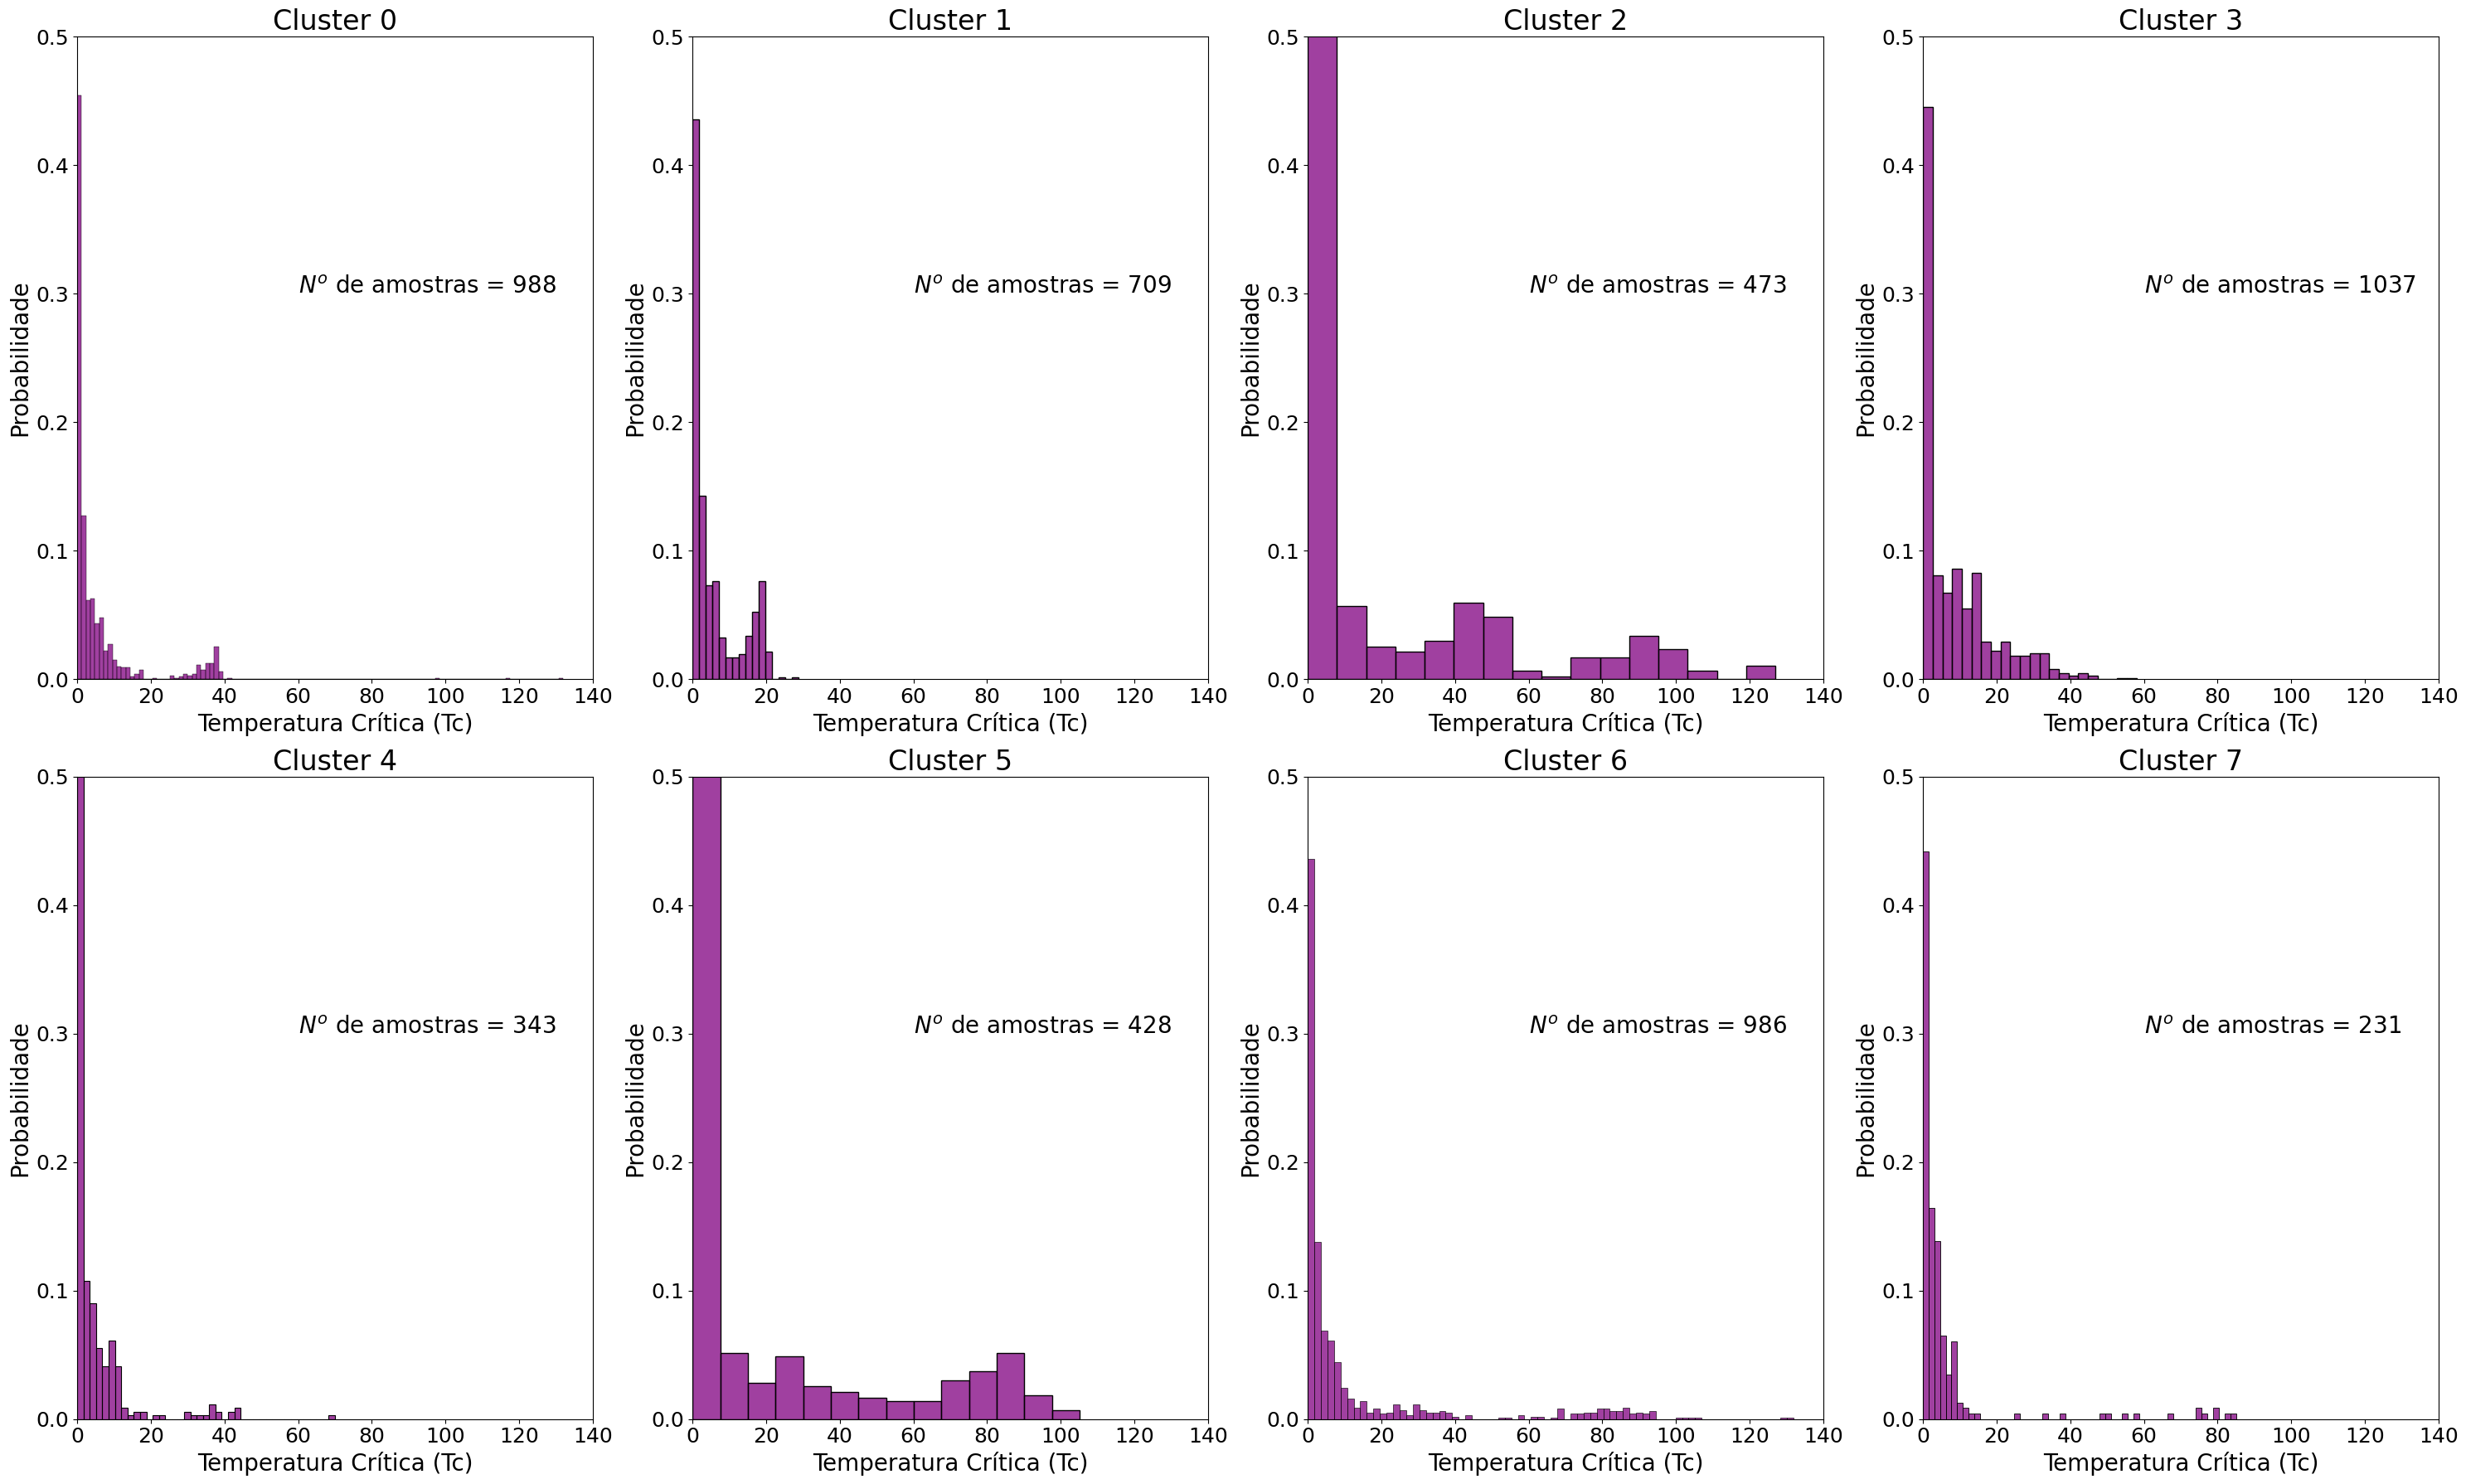

In [27]:
fig, axs = plt.subplots(2, 4, figsize=(30, 18))
axs = axs.flatten()


count = 0
for cluster in valid_clusters: 
    idx = np.where(cluster_labels == cluster)[0]

    axs[count].set_xlabel("Temperatura Crítica (Tc)", fontsize=20)
    axs[count].set_ylabel("Probabilidade", fontsize=20)

    X_cluster = X_train.iloc[idx]
    y_cluster = y_train.iloc[idx]

    sns.histplot(y_cluster, ax=axs[count], kde=False, stat="probability", color="purple") 
    coord_x = max(y_cluster)/2 
    axs[count].annotate(fr"$N^o$ de amostras = {len(y_cluster)}", xy=(60, 0.3), fontsize=20)
    axs[count].set_title(f"Cluster {cluster}", fontsize=24)
    axs[count].set_xlim(0, 140)
    axs[count].set_ylim(0, 0.5)
    axs[count].tick_params(axis='both', labelsize=18) 


    count += 1
    if count >= len(X_train.columns): 
        break

plt.tight_layout()
plt.show()

***

In [ ]:
study_name = "optimization_clusters_gam_teste25_02_2026_09_06_01"
storage_url = "sqlite:///../Optuna_files/optimization_clusters_gam_linear_terms.db"

study_gam_linear_terms = optuna.load_study(study_name=study_name, storage=storage_url)

### 🗂️ **References!**

[1] Sommer, Timo, et al. “3DSC - a Dataset of Superconductors Including Crystal Structures”. Scientific Data, v. 10, n. 1, novembro de 2023, p. 816. www.nature.com, https://doi.org/10.1038/s41597-023-02721-y.
